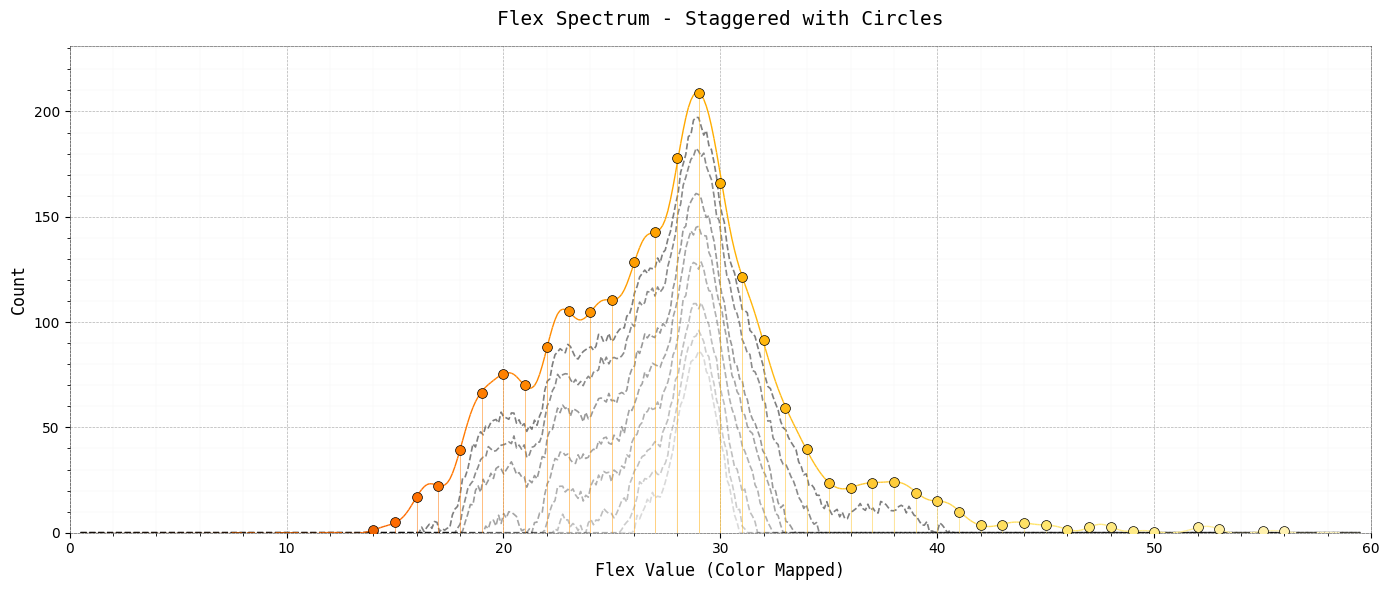

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.interpolate import make_interp_spline

def save_spectrum_strict_trend_staggered_circles(csv_file_path):
    # --- 1. Read and clean data ---
    try:
        df = pd.read_csv(csv_file_path)
    except UnicodeDecodeError:
        df = pd.read_csv(csv_file_path, encoding='gbk')

    df = df[~df['time'].isin(['01:14:58', '01:14:31'])]
    df['flex'] = pd.to_numeric(df['flex'], errors='coerce')
    df = df.dropna(subset=['flex'])
    df = df[df['flex'] <= 60]

    # --- 2. Calculate histogram data ---
    flex_values = df['flex'].values
    counts, bins = np.histogram(flex_values, bins=60, range=(0, 60))
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # --- 3. Generate smooth main curve ---
    x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 500)
    spl = make_interp_spline(bin_centers, counts, k=3)
    y_smooth = spl(x_smooth)
    y_smooth = np.maximum(y_smooth, 0)

    # --- 4. Setup transparent canvas ---
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_alpha(0)
    ax.set_facecolor('none')

    # --- 5. Color map ---
    custom_colors = ["#3b1d00", "#ff6a00", "#ffb000", "#ffe66d", "#fff7cc"]
    cmap_custom = LinearSegmentedColormap.from_list("custom_fire", custom_colors, N=256)
    norm = plt.Normalize(0, 60)

    # --- 6. Draw bottom staggered black lines ---
    np.random.seed(42)
    num_messy_lines = 8

    layer_gap = counts.max() * 0.08
    noise_limit = layer_gap * 0.45

    for i in range(num_messy_lines):
        random_phase = np.random.uniform(0, 2 * np.pi)
        wave_noise = np.sin(x_smooth * 0.15 + random_phase) * (noise_limit * 0.6)
        random_jitter = np.random.uniform(-noise_limit * 0.4, noise_limit * 0.4, size=len(x_smooth))
        total_noise = wave_noise + random_jitter

        base_y = y_smooth - ((i + 1) * layer_gap)
        y_messy = base_y + total_noise

        y_messy = np.minimum(y_messy, y_smooth - (layer_gap * 0.3))
        y_messy = np.maximum(y_messy, 0)

        alpha_val = 0.5 - (i * 0.05)
        if alpha_val < 0.1:
            alpha_val = 0.1

        ax.plot(
            x_smooth, y_messy,
            color='black',
            alpha=alpha_val,
            linewidth=1.2,
            linestyle='--',
            zorder=1
        )

    # --- 7. Draw vertical lines and intersection circles ---
    all_ticks = np.arange(0, 61, 1)

    for x_val in all_ticks:
        idx = (np.abs(x_smooth - x_val)).argmin()
        y_val = y_smooth[idx]

        if y_val > 0.1:
            line_color = cmap_custom(norm(x_val))

            ax.vlines(
                x=x_val, ymin=0, ymax=y_val,
                colors=line_color,
                linestyles='-',
                linewidth=0.7,
                alpha=0.5,
                zorder=2
            )

            ax.scatter(
                x_val, y_val,
                color=line_color,
                s=50,
                zorder=6,
                edgecolors='black',
                linewidth=0.5
            )

    # --- 8. Draw main gradient curve ---
    points = np.array([x_smooth, y_smooth]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap_custom, norm=norm)
    lc.set_array(x_smooth)
    lc.set_linewidth(1.0)
    lc.set_zorder(5)
    ax.add_collection(lc)

    # --- 9. Restore axes and labels ---
    y_max = counts.max() * 1.15
    ax.set_xlim(0, 60)
    ax.set_ylim(0, y_max)

    ax.set_xticks(np.arange(0, 61, 10))
    ax.set_xticklabels(np.arange(0, 61, 10), fontsize=10, color='black')

    ax.minorticks_on()
    ax.grid(True, which='major', color='black', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
    ax.grid(True, which='minor', color='black', linestyle=':', linewidth=0.3, alpha=0.15, zorder=0)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_alpha(0.6)
        spine.set_linestyle('--')
        spine.set_linewidth(0.5)

    ax.set_ylabel('Count', color='black', fontsize=12, fontname='monospace')
    ax.set_xlabel('Flex Value (Color Mapped)', color='black', fontsize=12, fontname='monospace')
    ax.tick_params(axis='both', colors='black')

    plt.title(
        'Flex Spectrum - Staggered with Circles',
        color='black',
        fontsize=14,
        fontname='monospace',
        pad=15
    )

    plt.tight_layout()
    plt.savefig(
        'flex_spectrum_staggered_circles.png',
        dpi=500,
        transparent=True,
        bbox_inches='tight'
    )
    plt.show()

# Run function
file_path = 'data6_final.csv'
save_spectrum_strict_trend_staggered_circles(file_path)